In [1]:
import seaborn as sns 
import matplotlib.pyplot as plt 
import pandas as pd 
from sklearn.model_selection import train_test_split

In [2]:
titanic=sns.load_dataset('titanic')

In [3]:
titanic.head()
titanic.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [4]:
features=['pclass','sex','fare','embarked','age']
target=['survived']

In [5]:
from sklearn.impute import SimpleImputer 
imp_mean=SimpleImputer(strategy='mean')
titanic[['age']]=imp_mean.fit_transform(titanic[['age']])
imp_freq=SimpleImputer(strategy='most_frequent')
titanic[['embarked']]=imp_freq.fit_transform(titanic[['embarked']])

In [6]:
titanic.isna().sum()


survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [7]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
titanic['sex']=le.fit_transform(titanic['sex'])
titanic['embarked']=le.fit_transform(titanic['embarked'])
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,Third,man,True,NaN,Southampton,no,False
1,1,1,0,38.0,1,0,71.2833,0,First,woman,False,C,Cherbourg,yes,False
2,1,3,0,26.0,0,0,7.9250,2,Third,woman,False,NaN,Southampton,yes,True
3,1,1,0,35.0,1,0,53.1000,2,First,woman,False,C,Southampton,yes,False
4,0,3,1,35.0,0,0,8.0500,2,Third,man,True,NaN,Southampton,no,True


In [8]:
x=titanic[features]
y=titanic[target]

In [9]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [10]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
from sklearn.metrics import accuracy_score 
print('accuracy score is ',accuracy_score(y_test,y_pred))

accuracy score is  0.7541899441340782


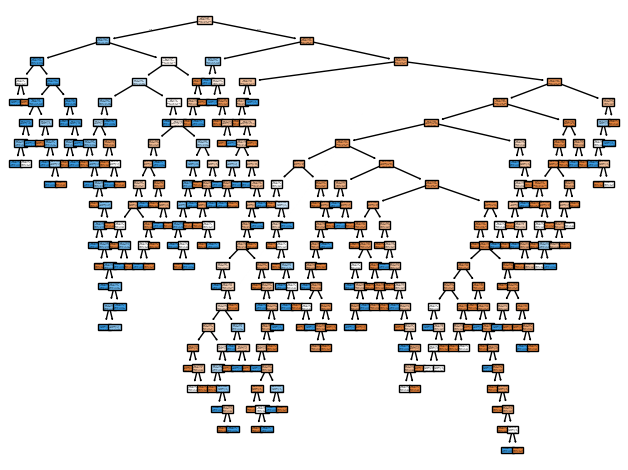

In [11]:
from sklearn.tree import plot_tree
plot_tree(
    model,
    feature_names=x_train.columns,
    class_names=['died','survived'],
    filled=True
)
plt.tight_layout()
plt.show()

In [12]:
depth=[4,5,6,7,8,9,10,15,67,100]
for depth in depth:
    model=DecisionTreeClassifier(max_depth=depth)
    model.fit(x_train,y_train)
    acc=model.score(x_train,y_train)
    print(f'model accuracy at depth {depth} is {acc}')

model accuracy at depth 4 is 0.8398876404494382
model accuracy at depth 5 is 0.8497191011235955
model accuracy at depth 6 is 0.8665730337078652
model accuracy at depth 7 is 0.8820224719101124
model accuracy at depth 8 is 0.8932584269662921
model accuracy at depth 9 is 0.9087078651685393
model accuracy at depth 10 is 0.9143258426966292
model accuracy at depth 15 is 0.9578651685393258
model accuracy at depth 67 is 0.9789325842696629
model accuracy at depth 100 is 0.9789325842696629


In [13]:
split=[2,4,5,6,7,8,9,10,15,67,100]
for split in split:
    model=DecisionTreeClassifier(max_depth=67,min_samples_split=split)
    model.fit(x_train,y_train)
    acc=model.score(x_train,y_train)
    print(f'model accuracy at depth {split} is {acc}')

model accuracy at depth 2 is 0.9789325842696629
model accuracy at depth 4 is 0.9550561797752809
model accuracy at depth 5 is 0.9438202247191011
model accuracy at depth 6 is 0.9382022471910112
model accuracy at depth 7 is 0.9297752808988764
model accuracy at depth 8 is 0.9213483146067416
model accuracy at depth 9 is 0.9129213483146067
model accuracy at depth 10 is 0.9073033707865169
model accuracy at depth 15 is 0.8848314606741573
model accuracy at depth 67 is 0.8342696629213483
model accuracy at depth 100 is 0.8258426966292135


In [14]:
full_tree=DecisionTreeClassifier(random_state=42)
full_tree.fit(x_train,y_train)
path=full_tree.cost_complexity_pruning_path(x_train,y_train)
cpp_alphas=path.ccp_alphas


In [15]:
tree=[]
for alphas in cpp_alphas:
    model=DecisionTreeClassifier(random_state=42,ccp_alpha=alphas)
    model.fit(x_train,y_train)
    tree.append((model,alphas))
best_acc=0
best_alpha=0
for model,alpha in tree:
    acc=model.score(x_train,y_train)
    if acc>best_acc:
        best_acc=acc
        best_alpha=alpha 


In [16]:
best_acc

0.9789325842696629

In [17]:
best_alpha

np.float64(0.0)

In [18]:
model=DecisionTreeClassifier(random_state=42,ccp_alpha=best_alpha)
model.fit(x_train,y_train)
model.score(x_train,y_train)

0.9789325842696629

In [19]:
from sklearn.ensemble import RandomForestClassifier 

In [31]:
rf=RandomForestClassifier(n_estimators=901,max_features='sqrt',oob_score=True,bootstrap=True)
rf.fit(x_train,y_train)
train_pred=rf.predict(x_train)
test_pred=rf.predict(x_test)
print(f'oob score is {rf.oob_score_}')
print(f'testing data accuracy is {accuracy_score(y_test,test_pred)}')

/opt/anaconda3/lib/python3.13/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


oob score is 0.800561797752809
testing data accuracy is 0.7877094972067039


In [33]:
from sklearn.ensemble import BaggingClassifier 
basemodel=DecisionTreeClassifier()
bc=BaggingClassifier(basemodel,n_estimators=901,oob_score=True)
bc.fit(x_train,y_train)
train_pred=bc.predict(x_train)
test_pred=bc.predict(x_test)
print(f'oob score is {bc.oob_score_}')
print(f'testing data accuracy is {accuracy_score(y_test,test_pred)}')

/opt/anaconda3/lib/python3.13/site-packages/sklearn/ensemble/_bagging.py:878: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


oob score is 0.7935393258426966
testing data accuracy is 0.7932960893854749
